## 01 Import Data

### 01-1 Setup Config

In [50]:
from dotenv import load_dotenv
from utils import init_mlflow
import os
import json
import copy
load_dotenv()
POSTGRES_URI = os.getenv('POSTGRES_URI')
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

# Set the stock code you want to analyze
STOCK_CODE = 2330

map_dict_path = '/app/data/column_mapping.json'
init_mlflow()
with open(map_dict_path, 'r', encoding='utf-8') as f:
    map_dict = json.load(f)
# '6770', '2337', '2344', '2303', '2408', '2515', '5521', '2542', '1316', '2442', '2485', '6285', '2455', '2412', '4977', '2367', '2313', '3037', '4958', '2327'

In [51]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict
import math
import time
import mlflow

%matplotlib inline

START_DATE = "2020-01-01"
END_DATE = time.strftime("%Y-%m-%d")

stock_dict_path = '/app/data/topk_stocks_by_industries.json'
with open(stock_dict_path, 'r', encoding='utf-8') as f:
    stock_dict = json.load(f)

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))
tqdm.pandas()
mlflow.set_experiment("LSTM_Test")
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

### 01-2 Load Data

In [52]:
[int(x) for x in stock_dict['半導體業']]

[2303, 2330, 2337, 2344, 2408, 2449, 2454, 3054, 3189, 3661, 3711, 6854, 8162]

In [53]:
def get_stock_data(stock_code, start_date: str, end_date: str, return_all=False):
    # Fetch data from PostgreSQL database
    table_name = f'daily_info_{stock_code}'
    query = f"""
    SELECT *
    FROM {table_name}
    WHERE stock_code_id = '{stock_code}'
      AND date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY date ASC;
    """
    df = pd.read_sql(query, POSTGRES_URI)

    # Rename columns using the mapping dictionary
    df.rename(columns=map_dict, inplace=True)
    return df

def get_stock_data_by_category(category, start_date: str, end_date: str):
    """
    category: 'ETF', '建材營造', '電子零組件業', '半導體業', '通信網路業'
    """
    stock_codes = stock_dict.get(category, [])
    stock_codes = [int(code) for code in stock_codes]
    all_data = []
    for code in stock_codes:
        try:
            df = get_stock_data(code, start_date, end_date)
            all_data.append(df)
        except Exception as e:
            print(f"Error fetching data for stock code {code}: {e}")
    final_df = pd.concat(all_data, ignore_index=True)
    # final_df = final_df.sort_values(by=['date', 'stock_code_id']).reset_index(drop=True)
    return final_df

df = get_stock_data_by_category("半導體業", START_DATE, END_DATE)
df.head()

,date,stock_code_id,market,capacity,turnover,open,high,low,close,change,transaction_volume,close_is_proxy
0,2020-01-02,2303,TWSE,32937461,544863192,16.45,16.65,16.40,16.55,0.10,5382,False
1,2020-01-03,2303,TWSE,48588354,792990409,16.55,16.55,16.15,16.30,-0.25,9541,False
2,2020-01-06,2303,TWSE,44790472,719002202,16.05,16.15,15.95,16.05,-0.25,5041,False
3,2020-01-07,2303,TWSE,39718117,633334895,16.05,16.15,15.80,16.00,-0.05,7401,False
4,2020-01-08,2303,TWSE,60494690,954618728,15.85,15.90,15.65,15.75,-0.25,9368,False


In [54]:
# Fill null values in 'change' using the values from 'change_new' (today's close - yesterday's close)
# df['change_new'] = df['close']-df['close'].shift(1)
# df['change'] = df['change'].fillna(df['change_new'])
# df = df.drop(columns=['change_new'])
df.isnull().sum()

date                   0
stock_code_id          0
market                 0
capacity               0
turnover               0
open                  13
high                  13
low                   13
close                 13
change                 0
transaction_volume     0
close_is_proxy         0
dtype: int64

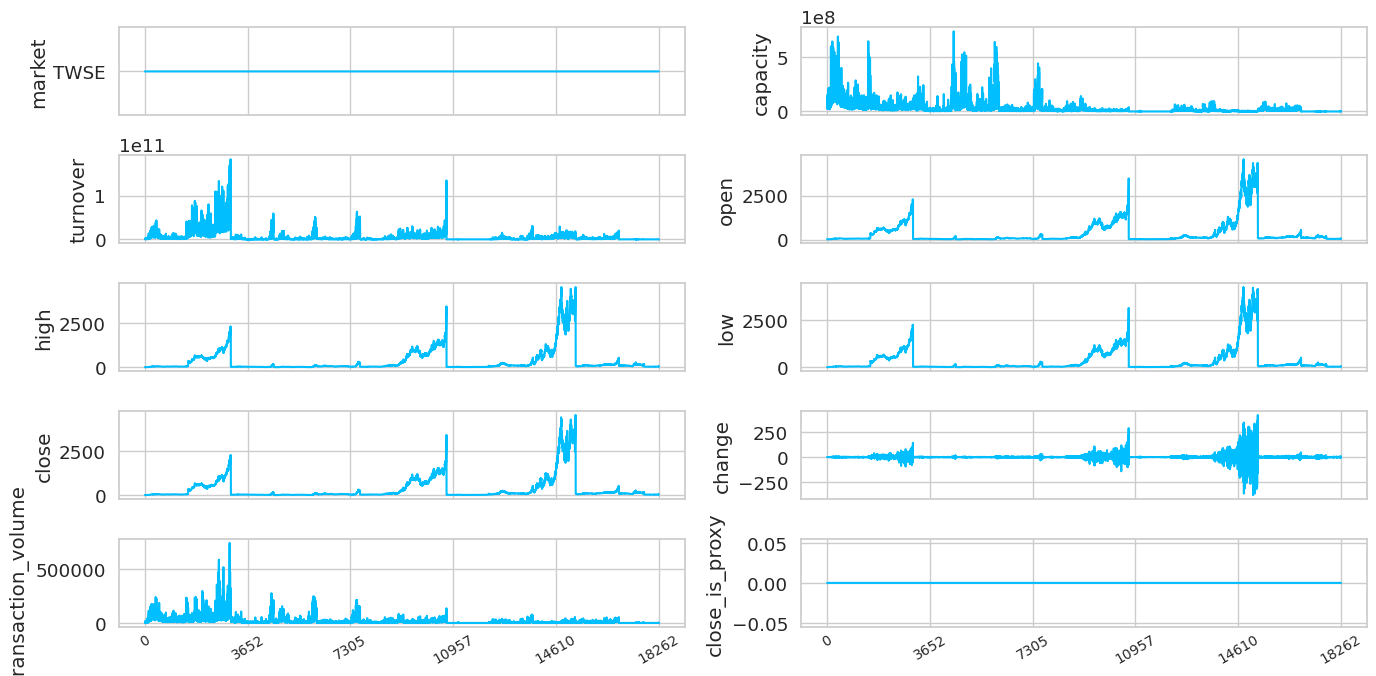

In [55]:
def data_plot(df):
    # Plot line charts
    df_plot = df.drop(columns=['stock_code_id', 'date'])

    ncols = 2
    nrows = int(round(df_plot.shape[1] / ncols, 0))

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
    for i, ax in enumerate(fig.axes):
        sns.lineplot(data=df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.tight_layout()
    plt.show()

data_plot(df)

### 01-3 Feature Engineering

In [56]:
# Multi-stock feature engineering (all stocks in the same industry)
train_ratio = 0.9
test_ratio = 1 - train_ratio

# OHLCV + change 欄位（除 close 外額外納入的 per-stock 欄位）
EXTRA_COLS = ['open', 'high', 'low', 'capacity', 'turnover', 'transaction_volume', 'change']

# 1) Pick all stock codes and align by date
selected_stocks = sorted(df['stock_code_id'].unique())
print(f"Selected stock codes: {selected_stocks}")

df_sub = df[df['stock_code_id'].isin(selected_stocks)].copy()
df_sub['date'] = pd.to_datetime(df_sub['date']).dt.normalize()

dup_cnt = int(df_sub.duplicated(subset=['date', 'stock_code_id']).sum())
if dup_cnt > 0:
    print(f"Found {dup_cnt} duplicate (date, stock_code_id) rows. Aggregating by mean.")

# 2) Pivot close
close_wide = (
    df_sub.groupby(['date', 'stock_code_id'], as_index=False)['close']
    .mean()
    .pivot_table(index='date', columns='stock_code_id', values='close', aggfunc='mean')
    .sort_index().ffill().bfill()
)
close_wide.columns = [f"close_{int(c)}" for c in close_wide.columns]

# 3) Pivot each extra column
extra_wide_list = []
for col in EXTRA_COLS:
    w = (
        df_sub.groupby(['date', 'stock_code_id'], as_index=False)[col]
        .mean()
        .pivot_table(index='date', columns='stock_code_id', values=col, aggfunc='mean')
        .sort_index().ffill().bfill()
    )
    w.columns = [f"{col}_{int(c)}" for c in w.columns]
    extra_wide_list.append(w)

# 4) Return (pct_change of close)
ret_wide = close_wide.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
ret_wide.columns = [f"ret_{col.split('_')[1]}" for col in close_wide.columns]

# 5) Cross-stock summary features
market_mean_close = close_wide.mean(axis=1).to_frame('market_mean_close')
market_mean_ret   = ret_wide.mean(axis=1).to_frame('market_mean_ret')
rel_close = close_wide.sub(close_wide.mean(axis=1), axis=0)
rel_close.columns = [f"rel_{col}" for col in close_wide.columns]

# 6) Assemble — column order: close | extra... | ret | market | rel
feature_df = pd.concat(
    [close_wide] + extra_wide_list + [ret_wide, market_mean_close, market_mean_ret, rel_close],
    axis=1,
).dropna()

target_cols  = ret_wide.columns.tolist()
feature_cols = feature_df.columns.tolist()

# 7) Time-based split 9:1
n_total = len(feature_df)
n_train = int(n_total * train_ratio)

df_train = feature_df.iloc[:n_train].copy()
df_test  = feature_df.iloc[n_train:].copy()

df_X_train = df_train[feature_cols]
df_X_test  = df_test[feature_cols]
df_y_train = df_train[target_cols]
df_y_test  = df_test[target_cols]

print(f"Train set: {len(df_X_train)} samples")
print(f"Test set:  {len(df_X_test)} samples")
print(f"Feature count: {len(feature_cols)}")
print(f"Target columns ({len(target_cols)}): {target_cols}")

Selected stock codes: ['2303', '2330', '2337', '2344', '2408', '2449', '2454', '3054', '3189', '3661', '3711', '6854', '8162']
Found 2 duplicate (date, stock_code_id) rows. Aggregating by mean.
Train set: 1383 samples
Test set:  154 samples
Feature count: 132
Target columns (13): ['ret_2303', 'ret_2330', 'ret_2337', 'ret_2344', 'ret_2408', 'ret_2449', 'ret_2454', 'ret_3054', 'ret_3189', 'ret_3661', 'ret_3711', 'ret_6854', 'ret_8162']


In [57]:
feature_df.columns

Index(['close_2303', 'close_2330', 'close_2337', 'close_2344', 'close_2408',
       'close_2449', 'close_2454', 'close_3054', 'close_3189', 'close_3661',
       ...
       'rel_close_2344', 'rel_close_2408', 'rel_close_2449', 'rel_close_2454',
       'rel_close_3054', 'rel_close_3189', 'rel_close_3661', 'rel_close_3711',
       'rel_close_6854', 'rel_close_8162'],
      dtype='object', length=132)

In [58]:
# Scale features and targets (returns)
x_scaler = StandardScaler()
df_X_train_scaled = x_scaler.fit_transform(df_X_train.values)
df_X_test_scaled  = x_scaler.transform(df_X_test.values)

y_scaler = StandardScaler()
df_y_train_scaled = y_scaler.fit_transform(df_y_train.values)
df_y_test_scaled  = y_scaler.transform(df_y_test.values)

# ret_scales  = y_scaler.data_max_ - y_scaler.data_min_   # return 的 scaling range
ret_scales  = y_scaler.scale_   # return 的 scaling factor (std)
stock_codes = [int(col.split('_')[1]) for col in target_cols]

print('X_train_scaled shape:', df_X_train_scaled.shape)
print('y_train_scaled shape:', df_y_train_scaled.shape)
print('Return scales:', dict(zip(stock_codes, np.round(ret_scales, 6))))
print('Test y scaled (min/max):', df_y_test_scaled.min().round(4), df_y_test_scaled.max().round(4))

X_train_scaled shape: (1383, 132)
y_train_scaled shape: (1383, 13)
Return scales: {2303: np.float64(0.022601), 2330: np.float64(0.01896), 2337: np.float64(0.023612), 2344: np.float64(0.027548), 2408: np.float64(0.026817), 2449: np.float64(0.024257), 2454: np.float64(0.025325), 3054: np.float64(0.021267), 3189: np.float64(0.031878), 3661: np.float64(0.040862), 3711: np.float64(0.023078), 6854: np.float64(0.023783), 8162: np.float64(0.011538)}
Test y scaled (min/max): -7.7651 8.6638


## 02 Model Training

### 02-1 Create Sequences and Labels for training and testing

In [59]:
# Create sequences for multi-stock forecasting
SEQUENCE_LENGTH = 7  # Number of time steps to look back

def create_sequences(X_array, y_array, seq_len):
    X_out, y_out = [], []
    for i in range(len(X_array) - seq_len):
        X_out.append(X_array[i:i + seq_len])
        y_out.append(y_array[i + seq_len])  # shape (4,) — next day only
    return np.array(X_out), np.array(y_out)

X_train_np, y_train_np = create_sequences(df_X_train_scaled, df_y_train_scaled, SEQUENCE_LENGTH)
X_test_np,  y_test_np  = create_sequences(df_X_test_scaled,  df_y_test_scaled,  SEQUENCE_LENGTH)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32)

print('X_train shape:', X_train.shape, 'y_train shape:', y_train.shape)
print('X_test shape:',  X_test.shape,  'y_test shape:',  y_test.shape)

X_train shape: torch.Size([1376, 7, 132]) y_train shape: torch.Size([1376, 13])
X_test shape: torch.Size([147, 7, 132]) y_test shape: torch.Size([147, 13])


In [60]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])  # (batch, n_stocks)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [61]:
# Setup model parameters
params = {
    'input_size':  X_train.shape[2],
    'hidden_size': 64,
    'num_layers':  3,
    'output_size': y_train.shape[1],
    'dropout':     0.3,
}

model     = LSTMModel(**params).to(device)
loss_fn   = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size    = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset  = TensorDataset(X_test, y_test)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

num_epochs         = 100
train_hist         = []
train_rmse_ret_hist = []
rmse_hist_epochs   = []
EVAL_EVERY         = 5   # run full eval every N epochs to avoid redundant passes

def evaluate_metrics(model, data_loader, y_scaler, device):
    """Returns per-stock (rmse, r2) arrays over a data loader."""
    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            preds_scaled.append(model(X_batch.to(device)).cpu().numpy())
            trues_scaled.append(y_batch.numpy())
    preds_inv = y_scaler.inverse_transform(np.concatenate(preds_scaled))
    trues_inv = y_scaler.inverse_transform(np.concatenate(trues_scaled))
    rmse = np.sqrt(np.mean((preds_inv - trues_inv) ** 2, axis=0))
    r2   = np.array([r2_score(trues_inv[:, i], preds_inv[:, i])
                     for i in range(trues_inv.shape[1])])
    return rmse, r2

def plot_predictions(true_ret, pred_ret, stock_codes, split_name):
    n = len(stock_codes)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
    axes_flat = np.array(axes).flatten()
    for i, code in enumerate(stock_codes):
        ax = axes_flat[i]
        ax.plot(true_ret[:, i], label='Actual Return',    color='blue')
        ax.plot(pred_ret[:, i], label='Predicted Return', color='red', alpha=0.7)
        ax.set_title(f'Stock {code}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Daily Return')
        ax.grid(True)
        ax.legend()
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.suptitle(f'{split_name}: Actual vs Predicted Return — one-step-ahead', y=1.02)
    plt.tight_layout()
    plt.show()

best_rmse        = float('inf')
best_model_state = None

with mlflow.start_run(nested=True) as run:
    mlflow.log_params(params)
    for i, code in enumerate(stock_codes):
        mlflow.log_param(f'ret_scale_{code}', float(ret_scales[i]))

    for epoch in range(num_epochs):
        total_loss = 0.0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            loss = loss_fn(model(X_batch), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_hist.append(avg_loss)

        if (epoch + 1) % EVAL_EVERY == 0:
            rmse_by_stock, _ = evaluate_metrics(model, train_loader, y_scaler, device)
            train_rmse_ret   = float(rmse_by_stock.mean())
            train_rmse_ret_hist.append(train_rmse_ret)
            rmse_hist_epochs.append(epoch + 1)

            log_metrics = {'train_mse_scaled': avg_loss, 'train_rmse_ret_avg': train_rmse_ret}
            for idx, code in enumerate(stock_codes):
                log_metrics[f'train_rmse_ret_{code}'] = float(rmse_by_stock[idx])
            mlflow.log_metrics(log_metrics, step=epoch)

            train_msg = ', '.join(f'{code}: {rmse_by_stock[idx]:.4f}'
                                  for idx, code in enumerate(stock_codes))
            print(f'Epoch[{epoch+1}/{num_epochs}] - '
                  f'MSE(scaled): {avg_loss:.4f} - '
                  f'RMSE(ret avg): {train_rmse_ret:.4f} - {train_msg}')

            if train_rmse_ret < best_rmse:
                best_rmse        = train_rmse_ret
                best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)
    print(f'Best Train RMSE (ret avg): {best_rmse:.6f}')
    mlflow.pytorch.log_model(model, name='best_LSTM')

2026/05/07 04:03:07 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/07 04:03:07 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch[5/100] - MSE(scaled): 0.9814 - RMSE(ret avg): 0.0242 - 2303: 0.0222, 2330: 0.0186, 2337: 0.0232, 2344: 0.0269, 2408: 0.0262, 2449: 0.0237, 2454: 0.0250, 3054: 0.0210, 3189: 0.0314, 3661: 0.0402, 3711: 0.0225, 6854: 0.0229, 8162: 0.0114
Epoch[10/100] - MSE(scaled): 0.9241 - RMSE(ret avg): 0.0237 - 2303: 0.0215, 2330: 0.0182, 2337: 0.0226, 2344: 0.0261, 2408: 0.0254, 2449: 0.0234, 2454: 0.0244, 3054: 0.0206, 3189: 0.0309, 3661: 0.0394, 3711: 0.0220, 6854: 0.0227, 8162: 0.0113
Epoch[15/100] - MSE(scaled): 0.8783 - RMSE(ret avg): 0.0224 - 2303: 0.0206, 2330: 0.0168, 2337: 0.0216, 2344: 0.0244, 2408: 0.0238, 2449: 0.0220, 2454: 0.0230, 3054: 0.0200, 3189: 0.0292, 3661: 0.0378, 3711: 0.0205, 6854: 0.0213, 8162: 0.0106
Epoch[20/100] - MSE(scaled): 0.8111 - RMSE(ret avg): 0.0215 - 2303: 0.0194, 2330: 0.0161, 2337: 0.0205, 2344: 0.0229, 2408: 0.0226, 2449: 0.0215, 2454: 0.0220, 3054: 0.0192, 3189: 0.0279, 3661: 0.0369, 3711: 0.0196, 6854: 0.0209, 8162: 0.0102
Epoch[25/100] - MSE(scaled): 

2026/05/07 04:03:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/07 04:03:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 04:03:45 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it

🏃 View run salty-chimp-981 at: http://172.18.0.3:5000/#/experiments/2/runs/c752371d492c4c86abd59ed40c3cbed7
🧪 View experiment at: http://172.18.0.3:5000/#/experiments/2


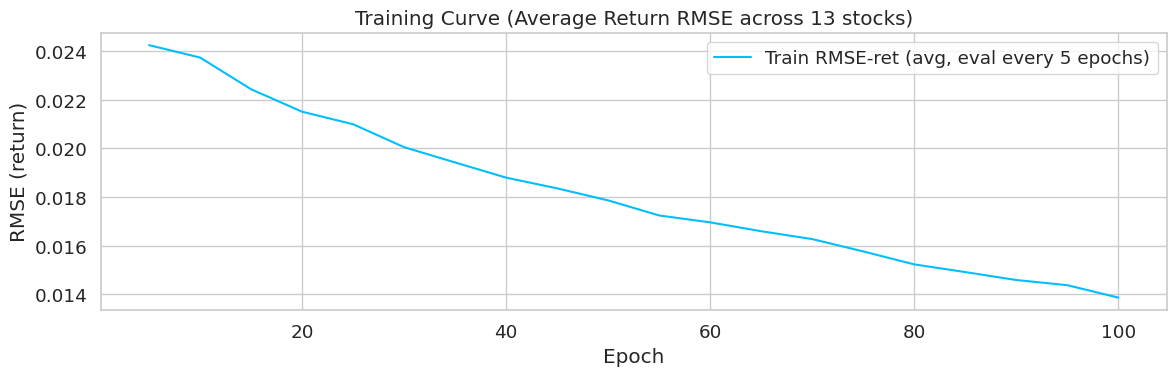

In [62]:
plt.figure(figsize=(12, 4))
plt.plot(rmse_hist_epochs, train_rmse_ret_hist,
         label=f'Train RMSE-ret (avg, eval every {EVAL_EVERY} epochs)')
plt.xlabel('Epoch')
plt.ylabel('RMSE (return)')
plt.legend()
plt.title(f'Training Curve (Average Return RMSE across {len(stock_codes)} stocks)')
plt.tight_layout()
plt.show()

## 03 Forecasting and evaluate

Test metrics by stock (one-step-ahead, return):
  Stock 2303 - RMSE: 0.049888, R²: -1.5056
  Stock 2330 - RMSE: 0.037339, R²: -2.3814
  Stock 2337 - RMSE: 0.085787, R²: -1.1351
  Stock 2344 - RMSE: 0.084292, R²: -1.5734
  Stock 2408 - RMSE: 0.076198, R²: -0.9882
  Stock 2449 - RMSE: 0.061304, R²: -1.5833
  Stock 2454 - RMSE: 0.053117, R²: -1.5153
  Stock 3054 - RMSE: 0.061848, R²: -0.8675
  Stock 3189 - RMSE: 0.093611, R²: -2.5995
  Stock 3661 - RMSE: 0.101232, R²: -5.3682
  Stock 3711 - RMSE: 0.061193, R²: -2.1189
  Stock 6854 - RMSE: 0.039609, R²: -0.1736
  Stock 8162 - RMSE: 0.032504, R²: -0.1676
Average RMSE: 0.064456
Average R²  : -1.6906


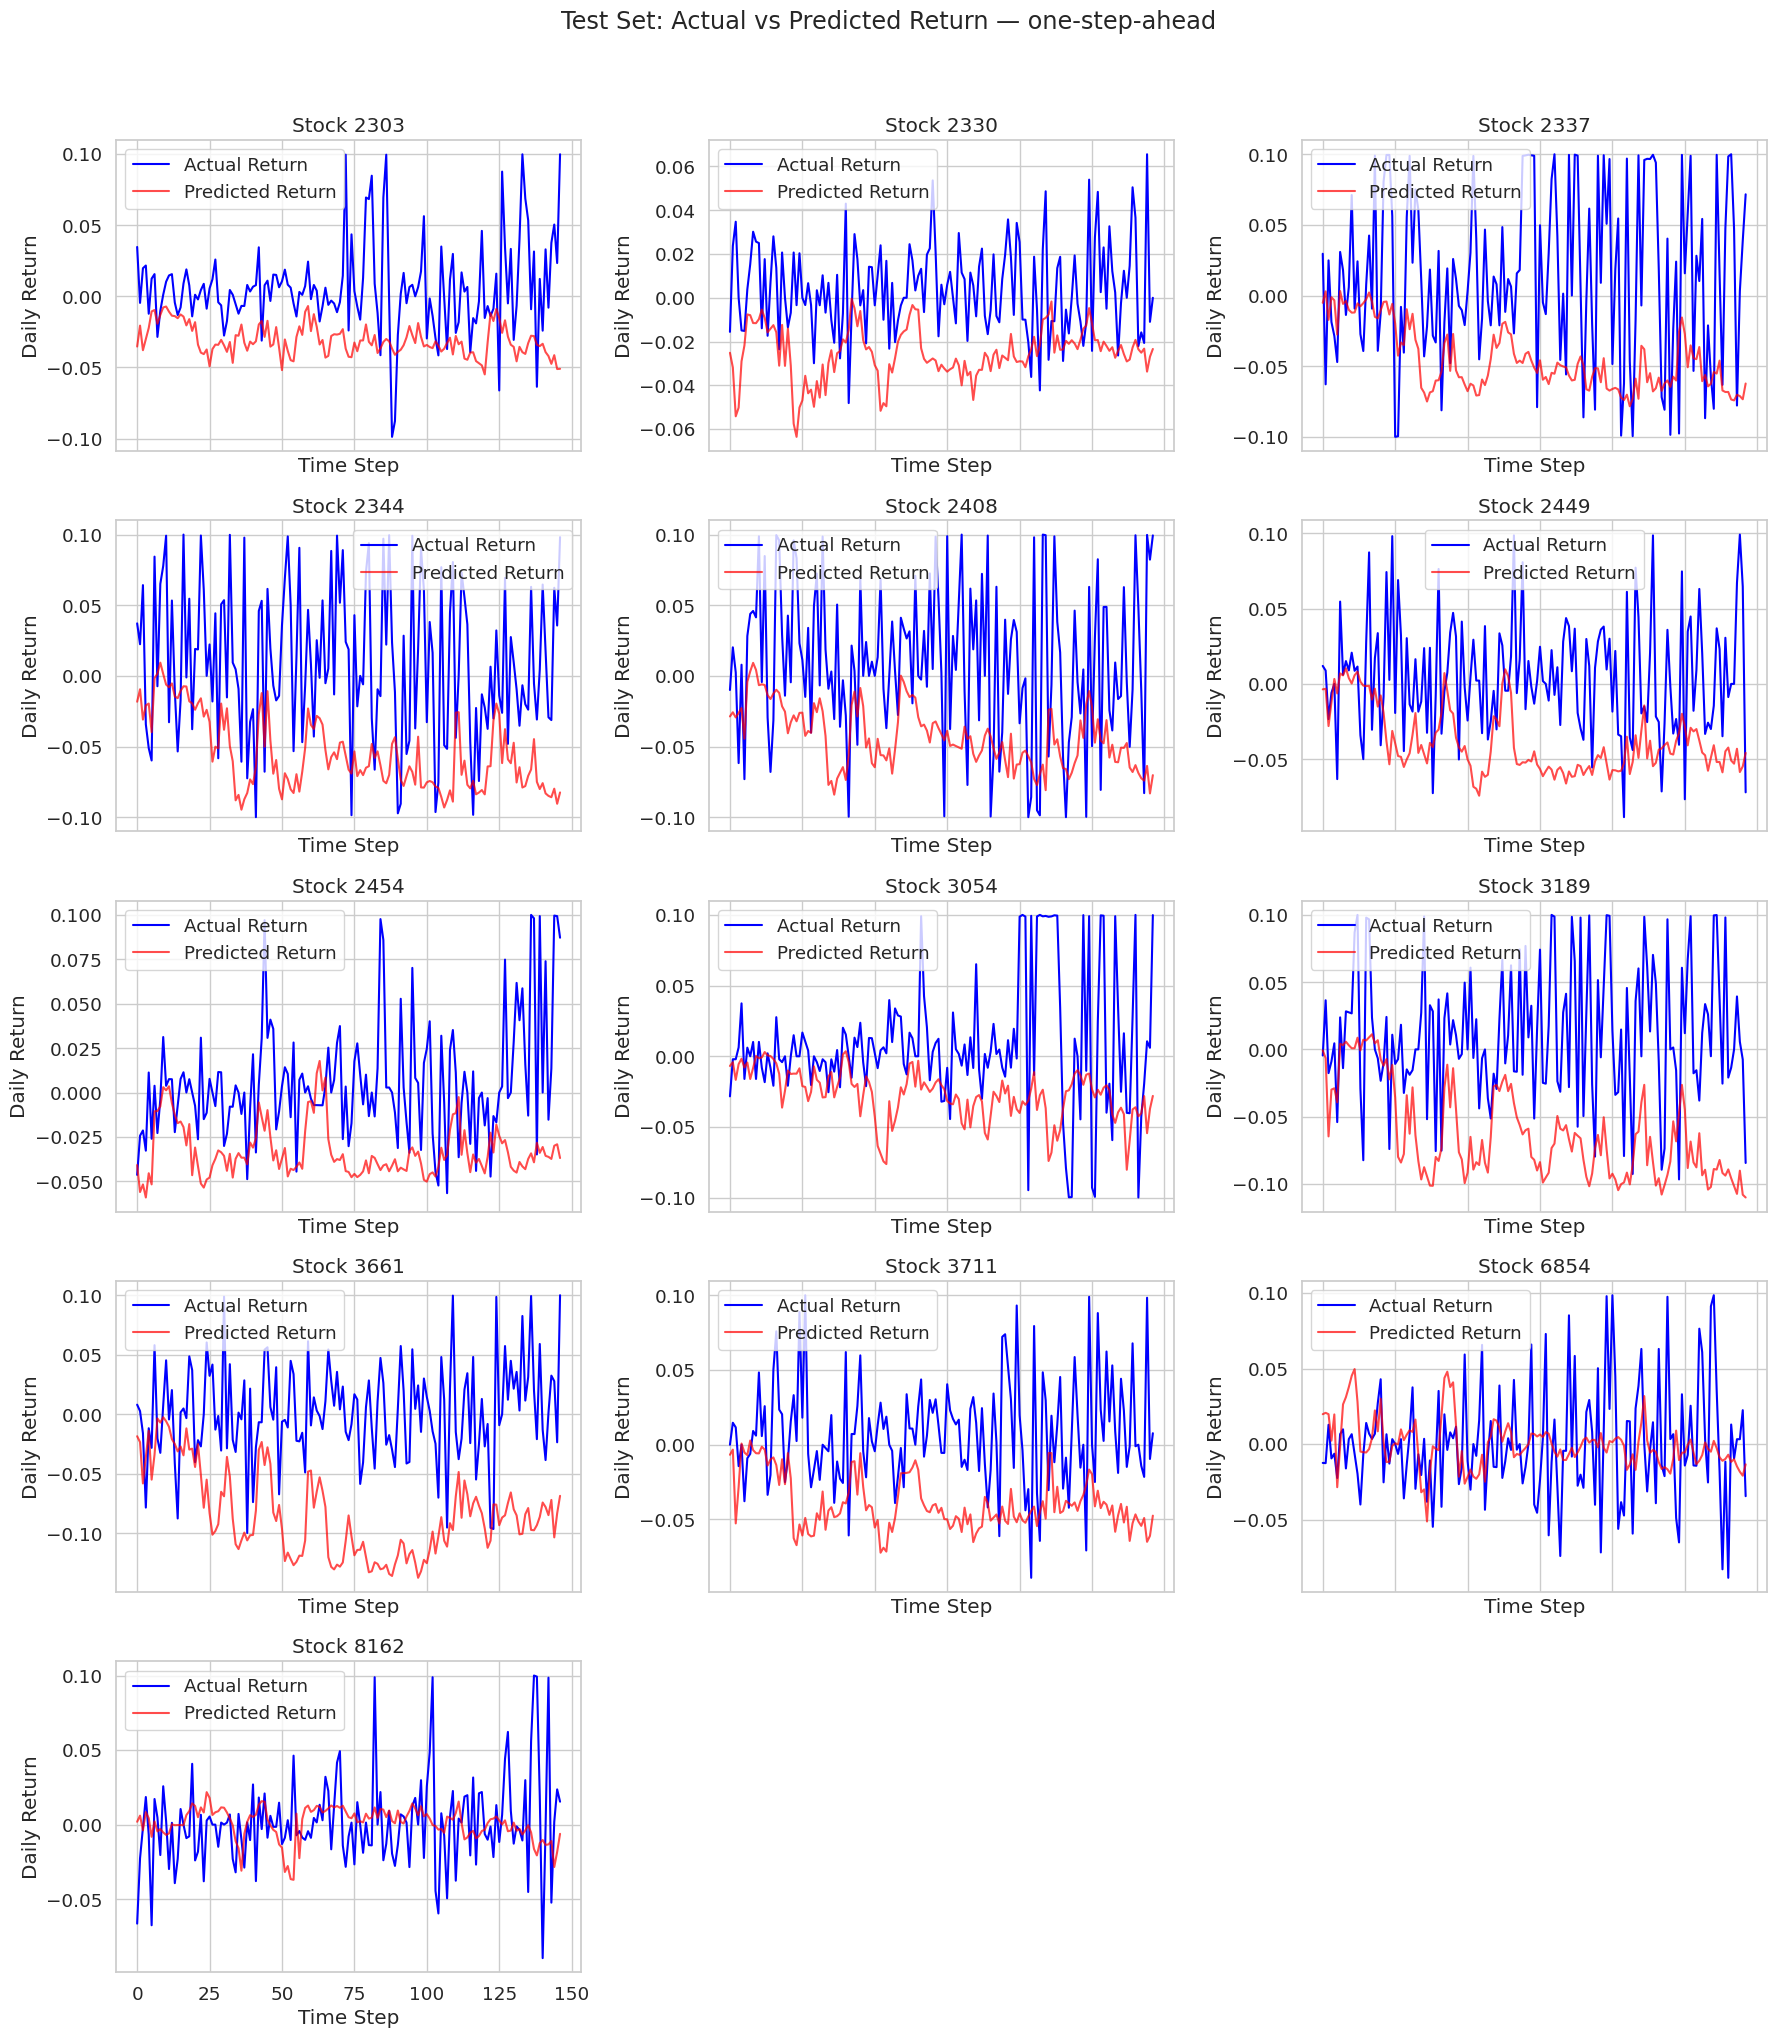


Forecast for next 1 day:
  Starting close: {2303: np.float64(91.4), 2330: np.float64(2250.0), 2337: np.float64(172.0), 2344: np.float64(108.5), 2408: np.float64(282.0), 2449: np.float64(328.5), 2454: np.float64(3430.0), 3054: np.float64(73.8), 3189: np.float64(482.5), 3661: np.float64(4565.0), 3711: np.float64(524.0), 6854: np.float64(154.0), 8162: np.float64(52.8)}
預測的 return：
  Day+1: 2303:-5.10%  2330:-2.34%  2337:-6.23%  2344:-8.25%  2408:-7.03%  2449:-4.58%  2454:-3.69%  3054:-2.80%  3189:-11.01%  3661:-6.85%  3711:-4.74%  6854:-1.34%  8162:-0.62%


In [63]:
def recursive_forecast(model, seed_X_scaled, n_steps, x_scaler, y_scaler,
                        last_close, feature_cols, device):
    """
    Autoregressively predicts n_steps days of returns then converts to prices.

    Column layout in feature_df (and thus x_scaler):
      [0  .. n_stocks-1]               → close_*
      [n_stocks .. n_stocks*(1+E)-1]   → extra cols (open/high/low/...) × n_stocks, E groups
      [n_stocks*(1+E) .. *2+E-1]       → ret_*
      [...] → market_mean_close, market_mean_ret, rel_close_*

    Only close and ret blocks are updated each step; other columns stay at their
    last known value (can't be auto-regressed from predicted return alone).
    """
    n_stocks = y_scaler.n_features_in_
    model.eval()
    window        = seed_X_scaled.copy()
    current_close = last_close.copy().astype(float)

    # Locate close and ret column indices by name
    close_idx = [feature_cols.index(c) for c in feature_cols if c.startswith('close_')]
    ret_idx   = [feature_cols.index(c) for c in feature_cols if c.startswith('ret_')]

    x_mean_close  = x_scaler.mean_[close_idx]
    x_scale_close = x_scaler.scale_[close_idx]

    forecasts_scaled = []
    with torch.no_grad():
        for _ in range(n_steps):
            x           = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            pred_scaled = model(x).cpu().numpy()[0]
            forecasts_scaled.append(pred_scaled)

            actual_ret    = y_scaler.inverse_transform(pred_scaled.reshape(1, -1))[0]
            current_close = current_close * (1 + actual_ret)

            # Roll window forward and update only close + ret; other cols stay frozen
            window = np.roll(window, -1, axis=0)
            window[-1, close_idx] = (current_close - x_mean_close) / x_scale_close
            window[-1, ret_idx]   = pred_scaled

    rets   = y_scaler.inverse_transform(np.array(forecasts_scaled))
    prices = np.cumprod(1 + rets, axis=0) * last_close
    return rets, prices

# ── Test set evaluation ──────────────────────────────────────────────────────
test_rmse, test_r2 = evaluate_metrics(model, test_loader, y_scaler, device)

model.eval()
preds_s, trues_s = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds_s.append(model(X_b.to(device)).cpu().numpy())
        trues_s.append(y_b.numpy())
test_pred_ret = y_scaler.inverse_transform(np.concatenate(preds_s))
test_true_ret = y_scaler.inverse_transform(np.concatenate(trues_s))

print('Test metrics by stock (one-step-ahead, return):')
for i, code in enumerate(stock_codes):
    print(f'  Stock {code} - RMSE: {test_rmse[i]:.6f}, R²: {test_r2[i]:.4f}')
print(f'Average RMSE: {test_rmse.mean():.6f}')
print(f'Average R²  : {test_r2.mean():.4f}')

plot_predictions(test_true_ret, test_pred_ret, stock_codes, 'Test Set')

# ── 1-day forecast from last test window ──────────────────────────────────────
FORECAST_HORIZON = 1
seed       = X_test_np[-1]
last_close = df_test[close_wide.columns].iloc[-1].values

forecast_rets, forecast_prices = recursive_forecast(
    model, seed, FORECAST_HORIZON, x_scaler, y_scaler,
    last_close, feature_cols, device
)

print(f'\nForecast for next {FORECAST_HORIZON} day:')
print(f'  Starting close: {dict(zip(stock_codes, last_close.round(1)))}')
print("預測的 return：")
for day, rets in enumerate(forecast_rets, 1):
    print(f"  Day+{day}: " + "  ".join(f"{c}:{r*100:+.2f}%" for c, r in zip(stock_codes, rets)))

Autoregressive evaluation over 30 steps (117 windows):

Step  | RMSE_2303  R²_2303 | RMSE_2330  R²_2330 | RMSE_2337  R²_2337 | RMSE_2344  R²_2344 | RMSE_2408  R²_2408 | RMSE_2449  R²_2449 | RMSE_2454  R²_2454 | RMSE_3054  R²_3054 | RMSE_3189  R²_3189 | RMSE_3661  R²_3661 | RMSE_3711  R²_3711 | RMSE_6854  R²_6854 | RMSE_8162  R²_8162
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Day+1  |  0.0438  -1.483 |  0.0370  -2.861 |  0.0846  -1.256 |  0.0853  -1.398 |  0.0735  -0.887 |  0.0602  -1.764 |  0.0451  -1.783 |  0.0583  -1.424 |  0.0887  -2.470 |  0.0992  -6.145 |  0.0583  -2.133 |  0.0370  -0.223 |  0.0272  -0.125
Day+2  |  0.0431  -1.412 |  0.0364  -2.740 |  0.0841  -1.184 |  0.0850  -1.379 |  0.0734  -0.868 |  0.0597  -1.620 |  0.0443  -1.696 |  0.0575  -

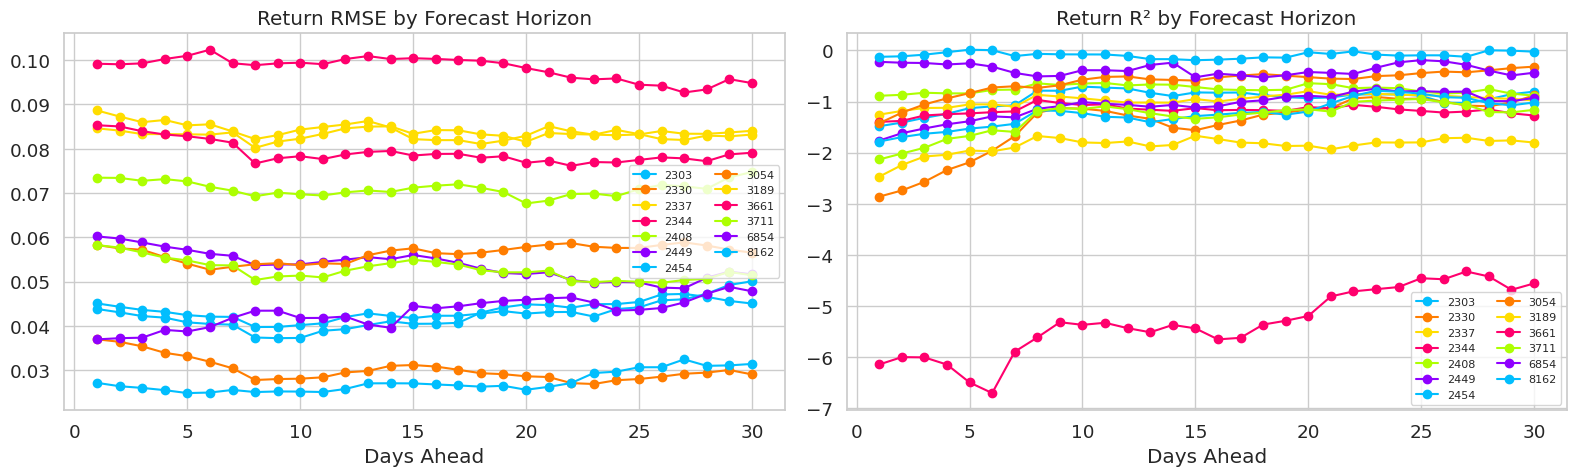

In [64]:
def evaluate_autoregressive_metrics(model, X_test_np, y_test_np, x_scaler, y_scaler,
                                     n_steps, stock_codes, df_test_closes, feature_cols, device):
    """
    Rolling-window backtest：對測試集每個起始點做 n_steps 天自回歸預測，
    計算每個 horizon（day+1 ~ day+n_steps）的 RMSE 和 R²（對 return 計算）。
    """
    n_stocks  = y_scaler.n_features_in_
    seq_len   = X_test_np.shape[1]
    n_windows = len(X_test_np) - n_steps
    if n_windows <= 0:
        raise ValueError(f'Test set too short for {n_steps}-step evaluation.')

    all_preds, all_trues = [], []
    for i in range(n_windows):
        last_close   = df_test_closes.iloc[i + seq_len - 1].values
        forecast_rets, _ = recursive_forecast(
            model, X_test_np[i], n_steps, x_scaler, y_scaler,
            last_close, feature_cols, device
        )
        actual_rets = y_scaler.inverse_transform(y_test_np[i:i + n_steps])
        all_preds.append(forecast_rets)
        all_trues.append(actual_rets)

    all_preds = np.array(all_preds)   # (n_windows, n_steps, n_stocks)
    all_trues = np.array(all_trues)

    rmse_per_step = np.sqrt(np.mean((all_preds - all_trues) ** 2, axis=0))
    r2_per_step   = np.array([
        [r2_score(all_trues[:, step, s], all_preds[:, step, s])
         for s in range(n_stocks)]
        for step in range(n_steps)
    ])

    print(f'Autoregressive evaluation over {n_steps} steps ({n_windows} windows):\n')
    header = 'Step  | ' + ' | '.join(f'RMSE_{c}  R²_{c}' for c in stock_codes)
    print(header)
    print('-' * len(header))
    for step in range(n_steps):
        row = f'Day+{step+1:<2} | '
        row += ' | '.join(
            f'{rmse_per_step[step, s]:7.4f}  {r2_per_step[step, s]:6.3f}'
            for s in range(n_stocks)
        )
        print(row)

    steps = np.arange(1, n_steps + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for s, code in enumerate(stock_codes):
        axes[0].plot(steps, rmse_per_step[:, s], marker='o', label=f'{code}')
        axes[1].plot(steps, r2_per_step[:, s],   marker='o', label=f'{code}')
    axes[0].set_title('Return RMSE by Forecast Horizon')
    axes[1].set_title('Return R² by Forecast Horizon')
    for ax in axes:
        ax.set_xlabel('Days Ahead')
        ax.legend(ncol=2, fontsize=8)
        ax.grid(True)
    plt.tight_layout()
    plt.show()

    return rmse_per_step, r2_per_step

rmse_steps, r2_steps = evaluate_autoregressive_metrics(
    model, X_test_np, y_test_np, x_scaler, y_scaler,
    n_steps=30,
    stock_codes=stock_codes,
    df_test_closes=df_test[close_wide.columns],
    feature_cols=feature_cols,
    device=device,
)

Train metrics by stock (one-step-ahead, return):
  Stock 2303 - RMSE: 0.012529, R²: 0.6938
  Stock 2330 - RMSE: 0.010321, R²: 0.7045
  Stock 2337 - RMSE: 0.013326, R²: 0.6821
  Stock 2344 - RMSE: 0.014368, R²: 0.7290
  Stock 2408 - RMSE: 0.014471, R²: 0.7097
  Stock 2449 - RMSE: 0.014489, R²: 0.6440
  Stock 2454 - RMSE: 0.015324, R²: 0.6352
  Stock 3054 - RMSE: 0.011556, R²: 0.7054
  Stock 3189 - RMSE: 0.019407, R²: 0.6307
  Stock 3661 - RMSE: 0.025358, R²: 0.6158
  Stock 3711 - RMSE: 0.013177, R²: 0.6744
  Stock 6854 - RMSE: 0.011520, R²: 0.7666
  Stock 8162 - RMSE: 0.004461, R²: 0.8512
Average RMSE: 0.013870
Average R²  : 0.6956


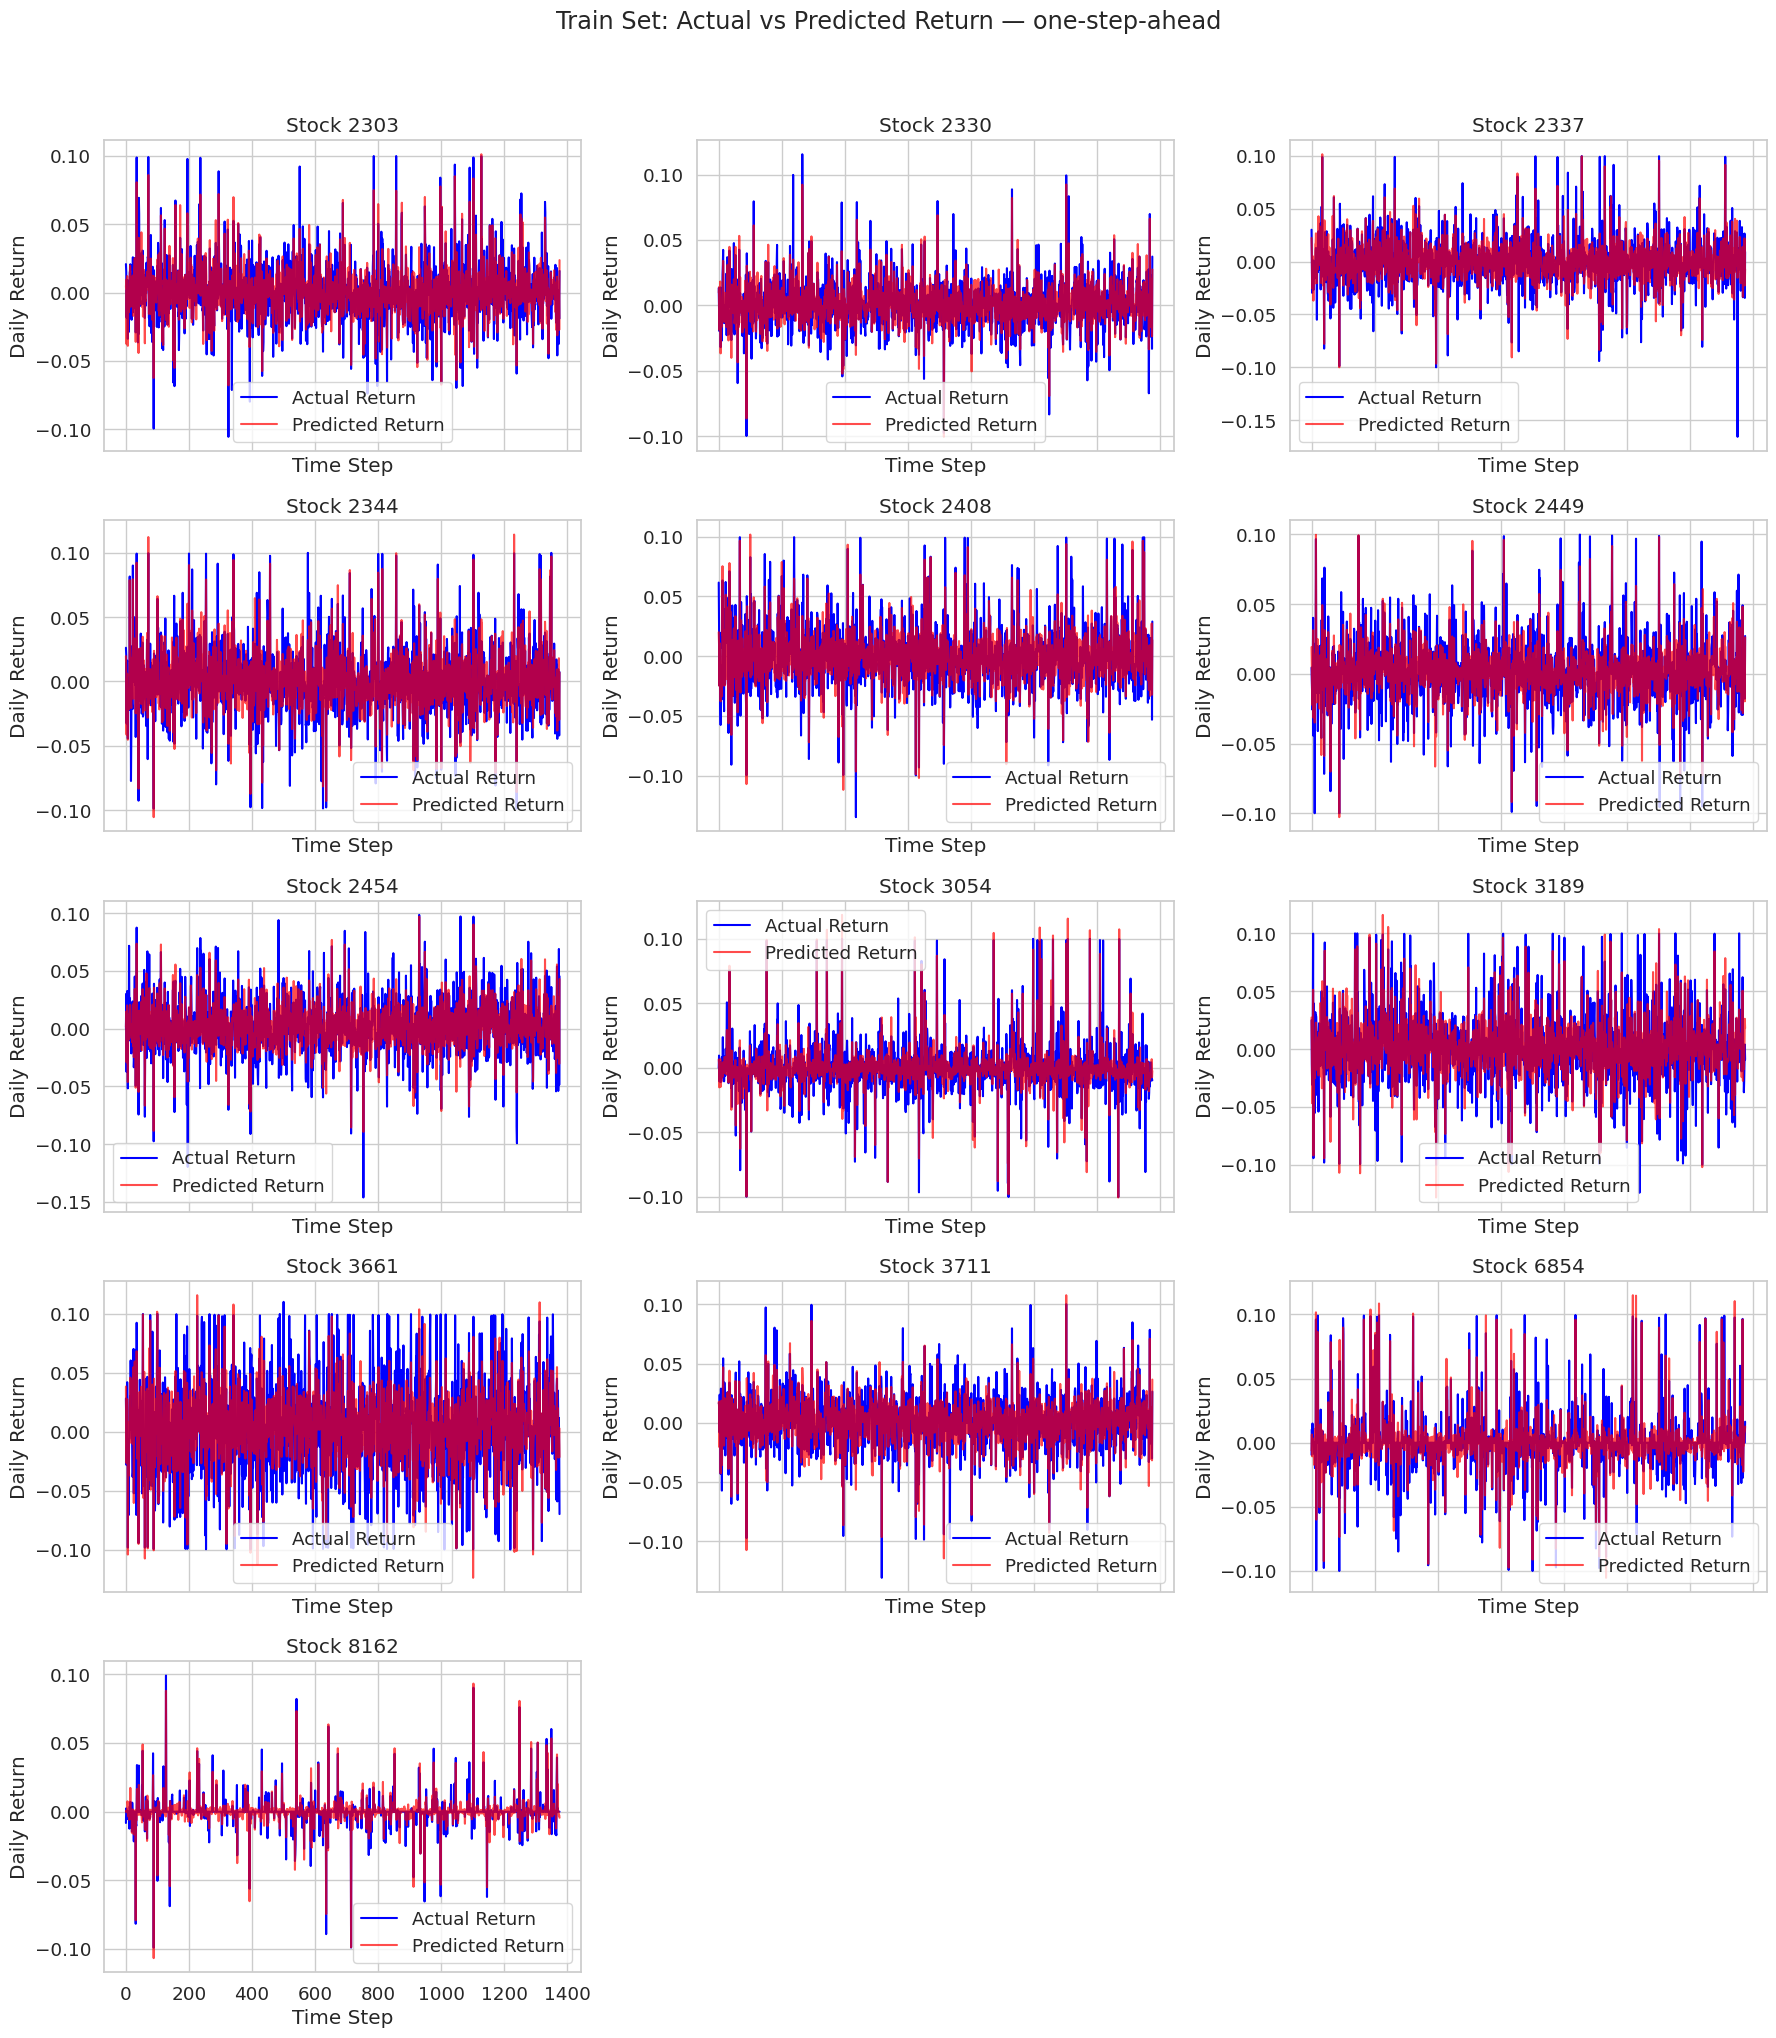

In [65]:
# Train set evaluation
train_rmse, train_r2 = evaluate_metrics(model, train_loader, y_scaler, device)

model.eval()
preds_s, trues_s = [], []
with torch.no_grad():
    for X_b, y_b in train_loader:
        preds_s.append(model(X_b.to(device)).cpu().numpy())
        trues_s.append(y_b.numpy())
train_pred_ret = y_scaler.inverse_transform(np.concatenate(preds_s))
train_true_ret = y_scaler.inverse_transform(np.concatenate(trues_s))

print('Train metrics by stock (one-step-ahead, return):')
for i, code in enumerate(stock_codes):
    print(f'  Stock {code} - RMSE: {train_rmse[i]:.6f}, R²: {train_r2[i]:.4f}')
print(f'Average RMSE: {train_rmse.mean():.6f}')
print(f'Average R²  : {train_r2.mean():.4f}')

plot_predictions(train_true_ret, train_pred_ret, stock_codes, 'Train Set')

In [66]:
print("Test y scaled (min/max):", df_y_test_scaled.min(), df_y_test_scaled.max())
# 若出現 < 0 或 > 1，代表測試資料超出訓練期範圍

Test y scaled (min/max): -7.765148437106335 8.663837835956093


Note: 目前流程改為 Train / Test = 9 : 1，避免將資料再切出 Validation 造成可訓練樣本不足。若後續要做模型選參，建議使用 rolling-window backtesting 取代固定 Validation 切分。

## 04 Save Model

In [67]:
from LSTM import save_forecast_to_db

# load best model
run_id       = run.info.run_id
loaded_model = mlflow.pytorch.load_model(f'runs:/{run_id}/best_LSTM').to(device)

forecast_df = save_forecast_to_db(
    model        = loaded_model,
    X_test_np    = X_test_np,
    df_test      = df_test,
    close_wide   = close_wide,
    x_scaler     = x_scaler,
    y_scaler     = y_scaler,
    feature_cols = feature_cols,
    stock_codes  = stock_codes,
    postgres_uri = POSTGRES_URI,
    device       = device,
)

Saved 1-day forecast to PostgreSQL table: lstm_prediction


In [68]:
forecast_df

,pred_date,2303_pred_price,2330_pred_price,2337_pred_price,2344_pred_price,2408_pred_price,2449_pred_price,2454_pred_price,3054_pred_price,3189_pred_price,3661_pred_price,3711_pred_price,6854_pred_price,8162_pred_price,inference_date
0,2026-05-07,86,2197,161,99,262,313,3303,71,429,4252,499,151,52,2026-05-07


In [69]:
# 先看 seed 視窗內的實際報酬率是什麼
seed_date_start = close_wide.index[n_train + len(df_X_test) - SEQUENCE_LENGTH]
seed_date_end   = close_wide.index[n_train + len(df_X_test) - 1]

print("Seed window actual returns:")
print(df_test[target_cols].iloc[-SEQUENCE_LENGTH:].to_string())
print(f"\nSeed period: {seed_date_start.date()} → {seed_date_end.date()}")


Seed window actual returns:
            ret_2303  ret_2330  ret_2337  ret_2344  ret_2408  ret_2449  ret_2454  ret_3054  ret_3189  ret_3661  ret_3711  ret_6854  ret_8162
date                                                                                                                                        
2026-04-27 -0.024161  0.036613  0.098485  0.064626  0.099515 -0.008741  0.000000  0.100000 -0.020913 -0.013049 -0.001008 -0.088496 -0.089552
2026-04-28  0.033012 -0.022075  0.100000  0.017039  0.048565  0.000000  0.073922 -0.099872 -0.013592 -0.038462  0.000000  0.012945 -0.002049
2026-04-29 -0.007989 -0.015801  0.047022 -0.029319 -0.010526  0.000000 -0.015296 -0.042674  0.000000  0.001250 -0.014127 -0.009585  0.098563
2026-04-30  0.037584 -0.020642 -0.077844 -0.031284 -0.082979  0.067019  0.013592 -0.019316  0.039370  0.032459 -0.021494  0.003226 -0.052336
2026-05-04  0.050453  0.065574  0.003247  0.062361  0.099768  0.099174  0.099617  0.010606  0.005682  0.027811  0.098326  0.00

## END